In [19]:
import pandas as pd
data=pd.read_csv('/content/ecommerce_sales_34500.csv')
print("dataset was succesfully loaded")

dataset was succesfully loaded


In [20]:
display(data.head())

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [21]:
data['High_Price'] = data['price'] > 5000

data['High_Discount'] = data['discount'] > 30

data['Late_Delivery'] = data['delivery_time_days'] > 7

data['High_Shipping_Cost'] = data['shipping_cost'] > 500

data['Returned_Product'] = data['returned'] == 'Yes'

data['Low_Profit'] = data['profit_margin'] < 10


print("\nDiagnosis Table:\n")

print(data[[
    'order_id',
    'category',
    'price',
    'discount',
    'delivery_time_days',
    'shipping_cost',
    'profit_margin',
    'returned',
    'High_Price',
    'High_Discount',
    'Late_Delivery',
    'High_Shipping_Cost',
    'Low_Profit'
]])

returned_orders = data[data['returned'] == 'Yes']

print("\nROOT CAUSE ANALYSIS\n")

print("Returned orders count:",
      len(returned_orders))

print(f"\nProducts with high price:{returned_orders['High_Price'].sum()}")
print(f"\nProducts with heavy discount:{returned_orders['High_Discount'].sum()}")
print(f"\nProducts with late delivery:{returned_orders['Late_Delivery'].sum()}")
print(f"\nProducts with high shipping cost:{returned_orders['High_Shipping_Cost'].sum()}")
print(f"\nProducts with low profit:{returned_orders['Low_Profit'].sum()}")


Diagnosis Table:

      order_id     category   price  discount  delivery_time_days  \
0      O100000         Home  164.08      0.15                   4   
1      O100001      Grocery   24.73      0.00                   6   
2      O100002  Electronics  175.58      0.05                   4   
3      O100003  Electronics   63.67      0.00                   6   
4      O100004         Home   16.33      0.15                   6   
...        ...          ...     ...       ...                 ...   
34495  O134495      Fashion   10.44      0.20                   3   
34496  O134496       Beauty    4.79      0.10                   6   
34497  O134497  Electronics  323.64      0.00                   6   
34498  O134498         Home   23.09      0.05                   6   
34499  O134499         Home   76.84      0.00                   6   

       shipping_cost  profit_margin returned  High_Price  High_Discount  \
0               7.88          31.17       No       False          False   
1 

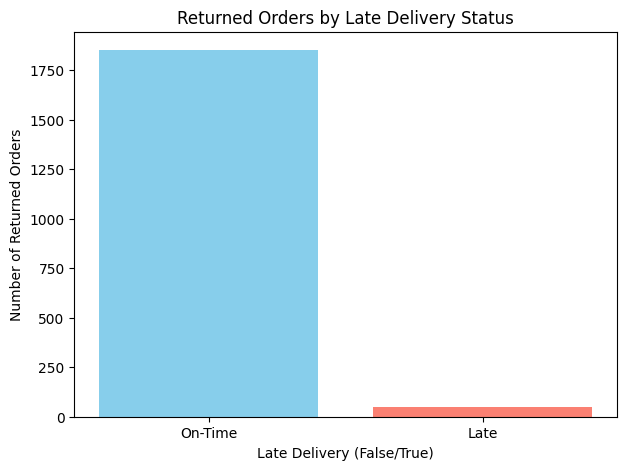

In [22]:
import matplotlib.pyplot as plt
late_delivery_counts = returned_orders['Late_Delivery'].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(late_delivery_counts.index.astype(str), late_delivery_counts.values, color=['skyblue', 'salmon'])
plt.title('Returned Orders by Late Delivery Status')
plt.xlabel('Late Delivery (False/True)')
plt.ylabel('Number of Returned Orders')
plt.xticks(ticks=[0, 1], labels=['On-Time', 'Late'])
plt.show()

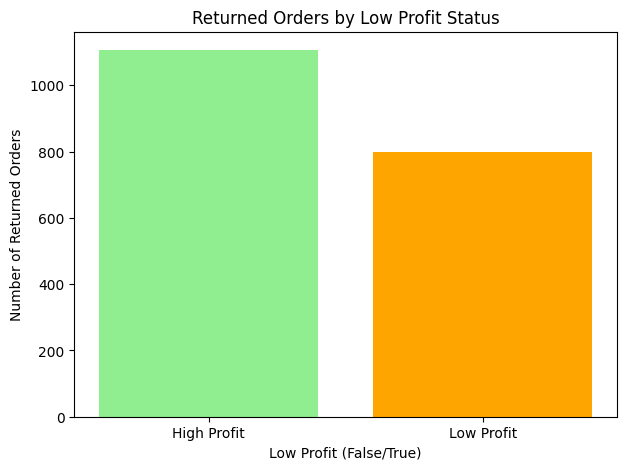

In [23]:

low_profit_counts = returned_orders['Low_Profit'].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(low_profit_counts.index.astype(str), low_profit_counts.values, color=['lightgreen', 'orange'])
plt.title('Returned Orders by Low Profit Status')
plt.xlabel('Low Profit (False/True)')
plt.ylabel('Number of Returned Orders')
plt.xticks(ticks=[0, 1], labels=['High Profit', 'Low Profit'])
plt.show()

<Figure size 1200x600 with 0 Axes>

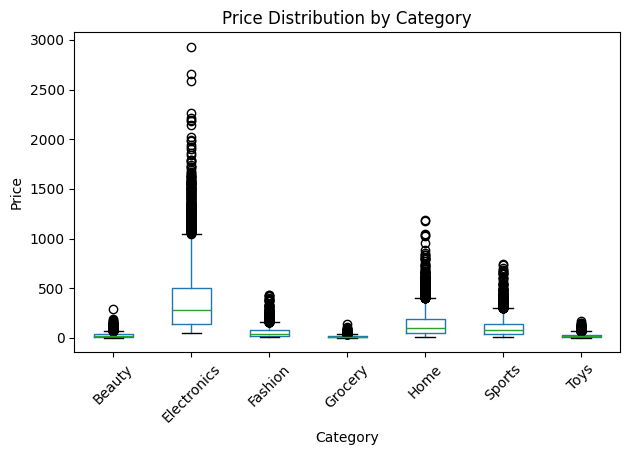

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
data.boxplot(column='price', by='category', grid=False, rot=45)
plt.title('Price Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Price')
plt.suptitle('')
plt.tight_layout()
plt.show()

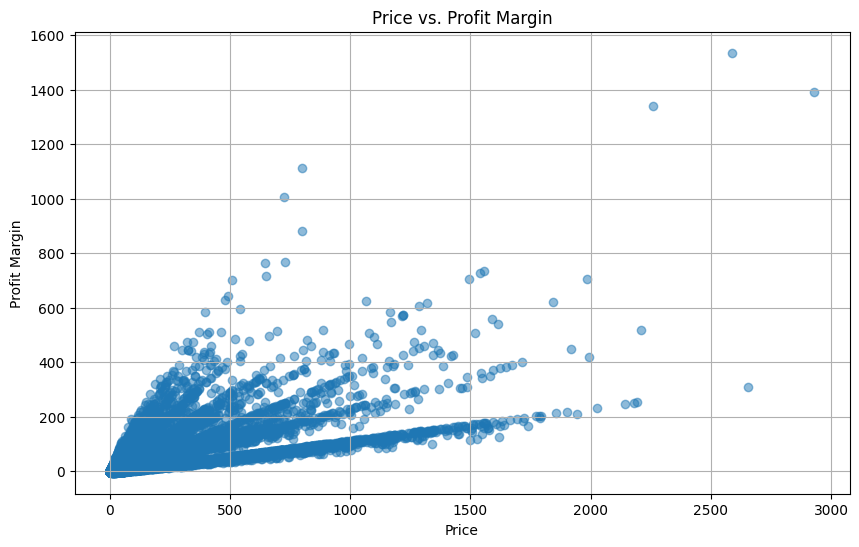

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(data['price'], data['profit_margin'], alpha=0.5)
plt.title('Price vs. Profit Margin')
plt.xlabel('Price')
plt.ylabel('Profit Margin')
plt.grid(True)
plt.show()

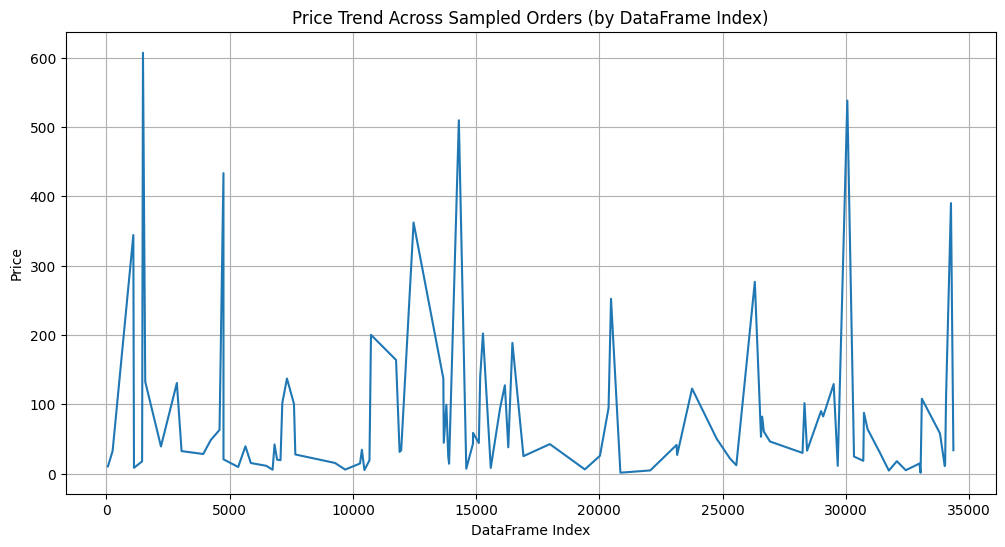

In [26]:
import matplotlib.pyplot as plt
sample_data = data.sample(n=100, random_state=42).sort_values(by='order_id')
plt.figure(figsize=(12, 6))
plt.plot(sample_data.index, sample_data['price'])
plt.title('Price Trend Across Sampled Orders (by DataFrame Index)')
plt.xlabel('DataFrame Index')
plt.ylabel('Price')
plt.grid(True)
plt.show()

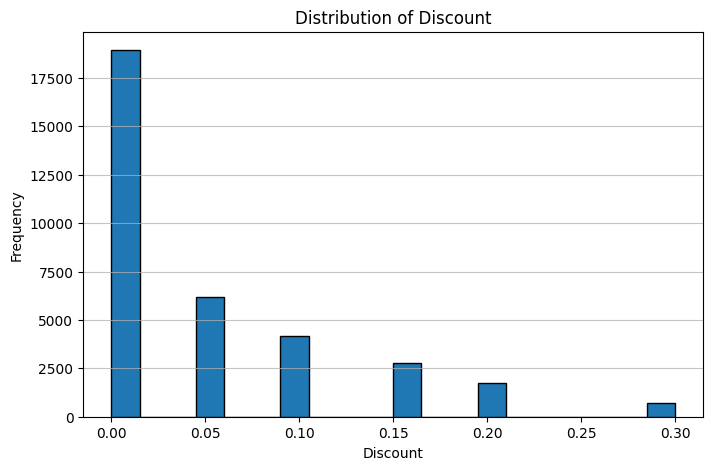

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data['discount'], bins=20, edgecolor='black')
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()